# Homework 17: pytorch implementation of Linear NN and CNN for letters A-Z classification

In [26]:
#for google colab
#!pip install torch pandas scikit-learn matplotlib tqdm --quiet

In [27]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

## Run this HW on google colab

In [28]:
# Set random seeds for reproducibility
SEED = 17
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    # paradoxically, but on my laptop MPS support is currently worse than CPU for this task
    else "cpu"
)
print(f'Device: {device}')

Device: cuda


## Load Data

In [29]:
from pathlib import Path

path = Path.cwd() / "data" / "A_Z Handwritten Data.csv"

df = pd.read_csv(path, header=None)

In [30]:
df.info()
print(f'Data shape: {df.shape}')
print(f'Number of classes: {df.iloc[:, 0].nunique()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372451 entries, 0 to 372450
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 2.2 GB
Data shape: (372451, 785)
Number of classes: 26


## Exapmle

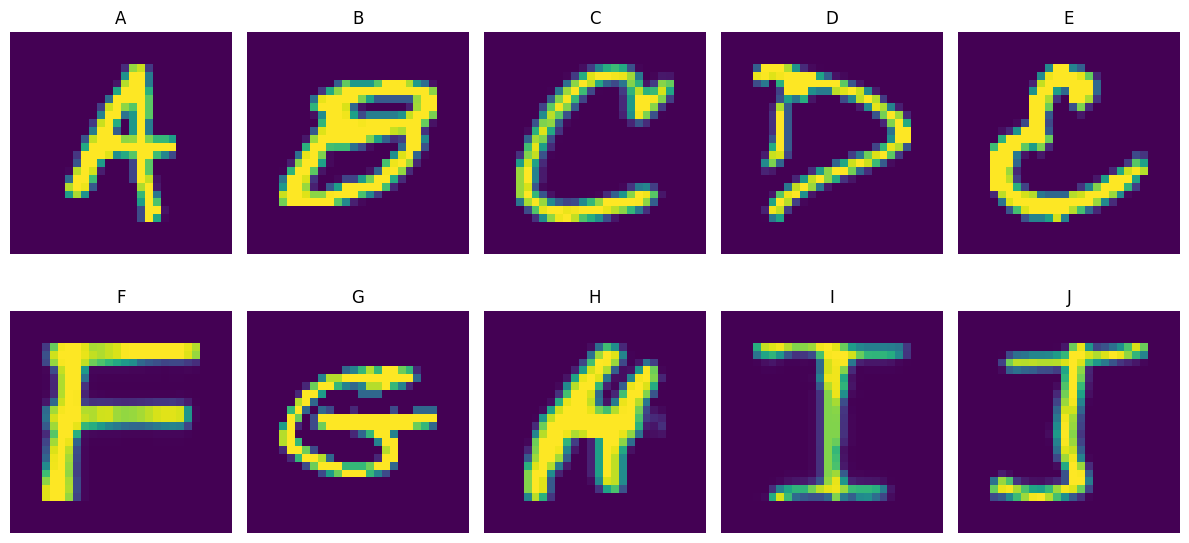

In [31]:
class_names = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    row = df[df.iloc[:, 0] == i].iloc[0]
    ax.imshow(row.iloc[1:].values.reshape(28, 28))
    ax.set_title(class_names[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

## DataLoader

In [32]:
class AZDataset(Dataset):
    def __init__(self, df):
        self.images = torch.tensor(df.iloc[:, 1:].values,
                                   dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
        self.labels = torch.tensor(df.iloc[:, 0].values,
                                   dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df.iloc[:, 0].values, # ensure class distribution is preserved in train/test split
)

train_dataset = AZDataset(train_df)
test_dataset  = AZDataset(test_df)

BATCH_SIZE = 512 # increased batch size to speed up training on GPU, can be reduced if running on CPU
# 256 work well on CPU, but GPU can 'eat' larger batches for faster training, so try 512 on colab

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # shuffling is important for training to ensure batches are different each epoch
    num_workers=0, # model crush on my devices when num_workers > 0, 
    # so try on colab, on small datasets num_workers=0 is often faster anyway,
    # but on larger datasets it can speed up data loading
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # no need to shuffle test data
    num_workers=0,
)

del train_df, test_df # free up memory

print(f'Train: {len(train_dataset)}; Test: {len(test_dataset)}')
print(f'Batch size: {BATCH_SIZE}')

Train: 297960; Test: 74491
Batch size: 1024


## Model

**Linear architecture**:

* **Flatten**: (Batch, 1, 28, 28) -> (Batch, 784)
* **Block 1**: Linear(784 -> 512) -> BatchNorm1d -> ReLU -> Dropout(0.3)
* **Block 2**: Linear(512 -> 256) -> BatchNorm1d -> ReLU -> Dropout(0.3)
* **Output**: Linear(256 -> 26)

`BatchNorm1d`: Standardizes the outputs of the linear layer. It stabilizes training, prevents gradients from exploding or vanishing, and helps the model learn much faster.

`Dropout(0.3)`: Randomly turns off 30% of neurons during training. This forces the network to learn redundant representations and strongly prevents overfitting.


In [34]:
class LinearNet_AZ(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 26),
        )

    def forward(self, x):
        return self.model(x)

A Convolutional Neural Network (`CNN`) built for comparison. It excels at image tasks because it preserves and analyzes the spatial structure (edges, shapes) of the visual data.

**CNN architecture**:

* **Conv Block 1**: Conv2d(1 -> 32, 3x3, pad=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2x2)
* **Conv Block 2**: Conv2d(32 -> 64, 3x3, pad=1) -> BatchNorm2d -> ReLU -> MaxPool2d(2x2)
* **Flatten**: (Batch, 64, 7, 7) -> (Batch, 3136)
* **Dense Block**: Dropout(0.3) -> Linear(3136 -> 128) -> ReLU -> Dropout(0.3)
* **Output**: Linear(128 -> 26)

`Conv2d`: Extracts visual features like edges and textures using small trainable filters.

`MaxPool2d(2x2)`: Reduces the spatial size (width and height) of the image by half, keeping only the most intense pixel values. This lowers memory usage and prevents overfitting.

In [35]:
# Create CNN for comparison in metrics
class CNN_AZ(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Dropout(0.3),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 26),
        )

    def forward(self, x):
        return self.model(x)

### Instantiate models and count parameters

In [36]:
linear_model = LinearNet_AZ().to(device)
cnn_model = CNN_AZ().to(device)

linear_params = sum(p.numel() for p in linear_model.parameters())
cnn_params = sum(p.numel() for p in cnn_model.parameters())

print(f'Linear model parameters: {linear_params}')
print(f'CNN model parameters:    {cnn_params}')

Linear model parameters: 541466
CNN model parameters:    423898


## Learning param
Use defaults for lr and rest

In [37]:
epochs = 15

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_model.parameters())

## Learning loop

for more information, use modern tools to optimize and refactor this loops

In [38]:
def train_loop(dataloader, model, loss_fn, optimizer, epoch):
    """
    Function to train the model for one epoch.
    It iterates over the dataloader, computes predictions,
    calculates loss, and updates model weights.
    It also tracks and prints average loss and accuracy for the epoch.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    tqdm_loader = tqdm(dataloader, unit='batch', desc=f'Epoch {epoch + 1}')
    for X, y in tqdm_loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad(set_to_none=True) # more efficient way to zero gradients
        loss.backward()
        optimizer.step()

        batch_size = X.size(0) # number of samples in the current batch
        total_loss += loss.item() * batch_size
        correct += (pred.argmax(1) == y).sum().item()
        total += batch_size
        tqdm_loader.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f'Train — Loss: {avg_loss:.4f}, Accuracy: {100 * accuracy:.1f}%')
    return avg_loss, accuracy

@torch.inference_mode() # disables gradient tracking for evaluation, improving performance and reducing memory usage
def test_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        batch_size = X.size(0)
        total_loss += loss.item() * batch_size
        correct += (pred.argmax(1) == y).sum().item()
        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total
    print(f'Test  — Loss: {avg_loss:.4f}, Accuracy: {100 * accuracy:.1f}%')
    return avg_loss, accuracy

## Linear model

*test on 10 epochs for linear net, later train my models on google colab t4 gpu
| time  | device |
|-------|--------|
| -2:38 | mps    |
| -1:34 | cpu    |

In [39]:
%%time
history = {'train_loss': [], 'test_loss': [], 'train_accuracy': [], 'test_accuracy': []}
best_linear_acc = 0.0
best_linear_state = None

for t in range(epochs):
    train_loss, train_acc = train_loop(train_loader, linear_model, loss_fn, optimizer, epoch=t)
    test_loss, test_acc = test_loop(test_loader, linear_model, loss_fn)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_accuracy'].append(train_acc)
    history['test_accuracy'].append(test_acc)

    if test_acc > best_linear_acc:
        best_linear_acc = test_acc
        best_linear_state = {k: v.cpu().clone() for k, v in linear_model.state_dict().items()} # save best model state to CPU to avoid GPU memory issues

print(f'Best Linear test accuracy: {best_linear_acc}')

Epoch 1: 100%|██████████| 291/291 [00:14<00:00, 19.88batch/s, loss=0.1827]


Train — Loss: 0.4309, Accuracy: 88.8%
Test  — Loss: 0.1369, Accuracy: 96.2%


Epoch 2: 100%|██████████| 291/291 [00:11<00:00, 26.41batch/s, loss=0.1226]


Train — Loss: 0.1602, Accuracy: 95.4%
Test  — Loss: 0.0939, Accuracy: 97.3%


Epoch 3: 100%|██████████| 291/291 [00:10<00:00, 27.06batch/s, loss=0.0937]


...

Train — Loss: 0.0520, Accuracy: 98.3%
Test  — Loss: 0.0386, Accuracy: 98.9%


Epoch 14: 100%|██████████| 291/291 [00:11<00:00, 25.77batch/s, loss=0.0434]


Train — Loss: 0.0498, Accuracy: 98.4%
Test  — Loss: 0.0375, Accuracy: 99.0%


Epoch 15: 100%|██████████| 291/291 [00:11<00:00, 26.16batch/s, loss=0.0489]


Train — Loss: 0.0475, Accuracy: 98.5%
Test  — Loss: 0.0363, Accuracy: 99.0%
Best Linear test accuracy: 0.9900793384435703
CPU times: user 2min 55s, sys: 1.49 s, total: 2min 56s
Wall time: 3min 3s


## Learning curves

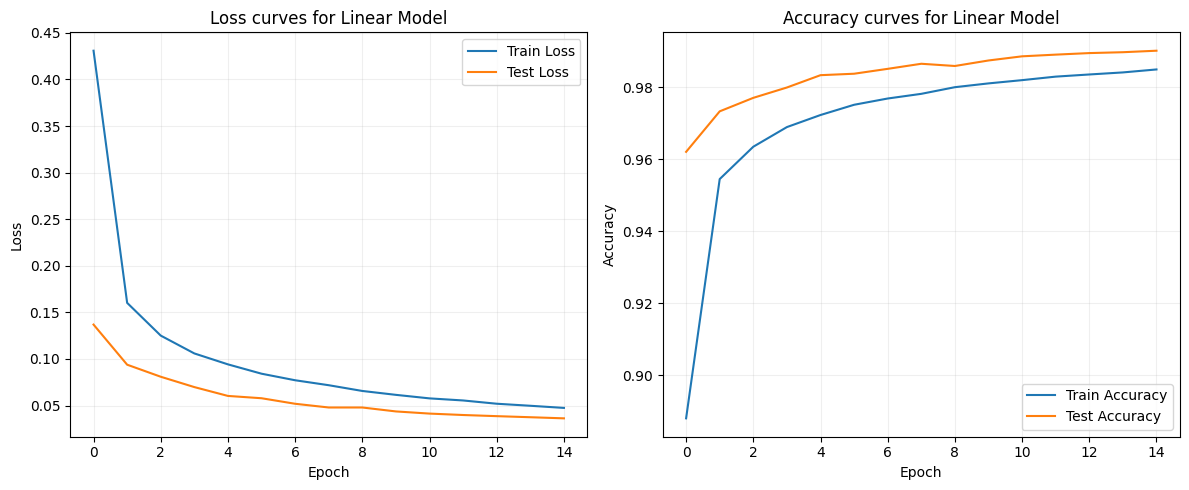

In [40]:
def plot_learning_curves(history, model_name='cool Model'):

    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

    axs[0].plot(history['train_loss'], label='Train Loss')
    axs[0].plot(history['test_loss'], label='Test Loss')
    axs[0].set(title=f'Loss curves for {model_name}', xlabel='Epoch', ylabel='Loss')
    axs[0].grid(True, alpha=0.2)
    axs[0].legend()

    axs[1].plot(history['train_accuracy'], label='Train Accuracy')
    axs[1].plot(history['test_accuracy'], label='Test Accuracy')
    axs[1].set(title=f'Accuracy curves for {model_name}', xlabel='Epoch', ylabel='Accuracy')
    axs[1].grid(True, alpha=0.2)
    axs[1].legend()

    fig.tight_layout()
    plt.show()

plot_learning_curves(history, model_name='Linear Model')

## Predict on random samples

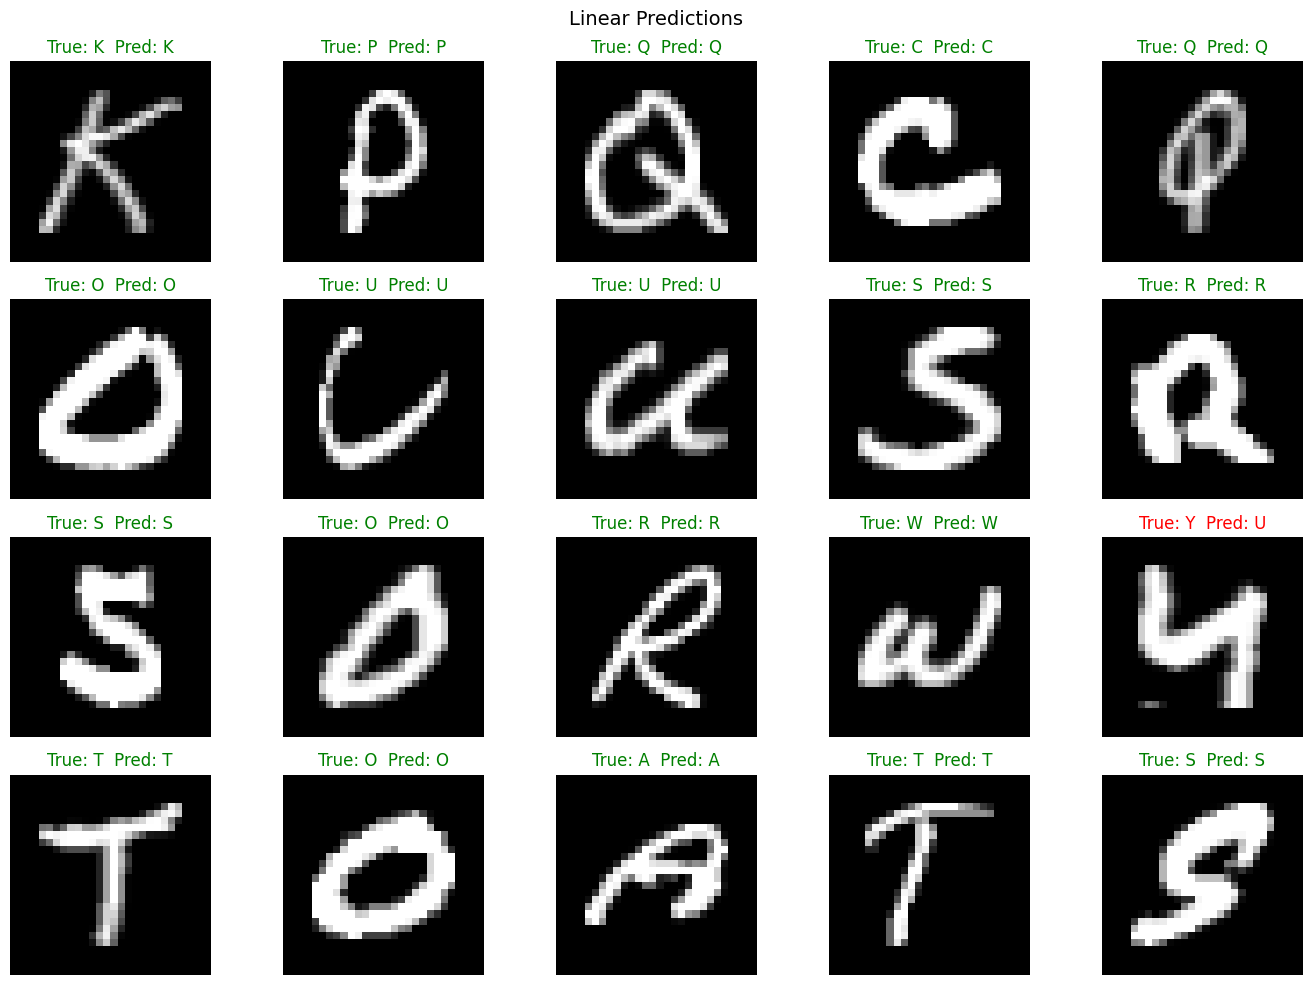

In [41]:
def plot_predictions(model=None, model_name='Linear', nrow=4, ncol=5, num_samples=20):
    if model is None:
        model = linear_model

    model.eval()
    indices = random.sample(range(len(test_dataset)), num_samples)
    fig, axes = plt.subplots(nrow, ncol, figsize=(14, 10))
    fig.suptitle(f'{model_name} Predictions', fontsize=14)

    with torch.inference_mode():
        for i, ax in enumerate(axes.flat):
            if i < num_samples:
                img, true_label = test_dataset[indices[i]]
                pred = model(img.unsqueeze(0).to(device))
                y_pred = pred.argmax(1).item()

                ax.imshow(img.squeeze().cpu(), cmap='gray')
                ax.set_title(
                    f'True: {class_names[true_label]}  Pred: {class_names[y_pred]}',
                    color='green' if y_pred == true_label else 'red'
                )
                ax.axis('off')

    fig.tight_layout()
    plt.show()

plot_predictions()

## CNN metrics

The homework requirement is completed by the Linear model. For comparison i wrote CNN, but it is slower and did not outperform the Linear model

In [42]:
%%time
def train_cnn_model(num_epochs=15):
    cnn_optimizer = torch.optim.Adam(cnn_model.parameters())
    cnn_history = pd.DataFrame(columns=['train_loss', 'test_loss', 'train_accuracy', 'test_accuracy'])
    best_cnn_acc = 0.0
    best_cnn_state = None

    for t in range(num_epochs):
        train_loss, train_acc = train_loop(train_loader, cnn_model, loss_fn, cnn_optimizer, epoch=t)
        test_loss, test_acc = test_loop(test_loader, cnn_model, loss_fn)

        new_row = pd.DataFrame([{
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
        }])
        cnn_history = pd.concat([cnn_history, new_row], ignore_index=True)

        if test_acc > best_cnn_acc:
            best_cnn_acc = test_acc
            best_cnn_state = {k: v.cpu().clone() for k, v in cnn_model.state_dict().items()}

    print(f'CNN parameters: {cnn_params:,}')
    print(f'CNN final test loss: {cnn_history["test_loss"].iloc[-1]:.4f}')
    print(f'CNN final test acc: {100 * cnn_history["test_accuracy"].iloc[-1]:.2f}%')

    return cnn_history, best_cnn_acc, best_cnn_state

cnn_history, best_cnn_acc, best_cnn_state = train_cnn_model()

Epoch 1: 100%|██████████| 291/291 [00:21<00:00, 13.41batch/s, loss=0.1873]


Train — Loss: 0.4111, Accuracy: 88.5%


<timed exec>:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Test  — Loss: 0.0927, Accuracy: 97.5%


Epoch 2: 100%|██████████| 291/291 [00:21<00:00, 13.29batch/s, loss=0.1316]


...

Train — Loss: 0.0572, Accuracy: 98.3%
Test  — Loss: 0.0346, Accuracy: 99.1%


Epoch 14: 100%|██████████| 291/291 [00:18<00:00, 16.07batch/s, loss=0.0639]


Train — Loss: 0.0557, Accuracy: 98.4%
Test  — Loss: 0.0340, Accuracy: 99.1%


Epoch 15: 100%|██████████| 291/291 [00:18<00:00, 15.88batch/s, loss=0.0330]


Train — Loss: 0.0528, Accuracy: 98.4%
Test  — Loss: 0.0330, Accuracy: 99.1%
CNN parameters: 423,898
CNN final test loss: 0.0330
CNN final test acc: 99.12%
CPU times: user 4min 47s, sys: 1.64 s, total: 4min 49s
Wall time: 5min 1s


### early stop on epoch 11 would be usefull to reduce time for training

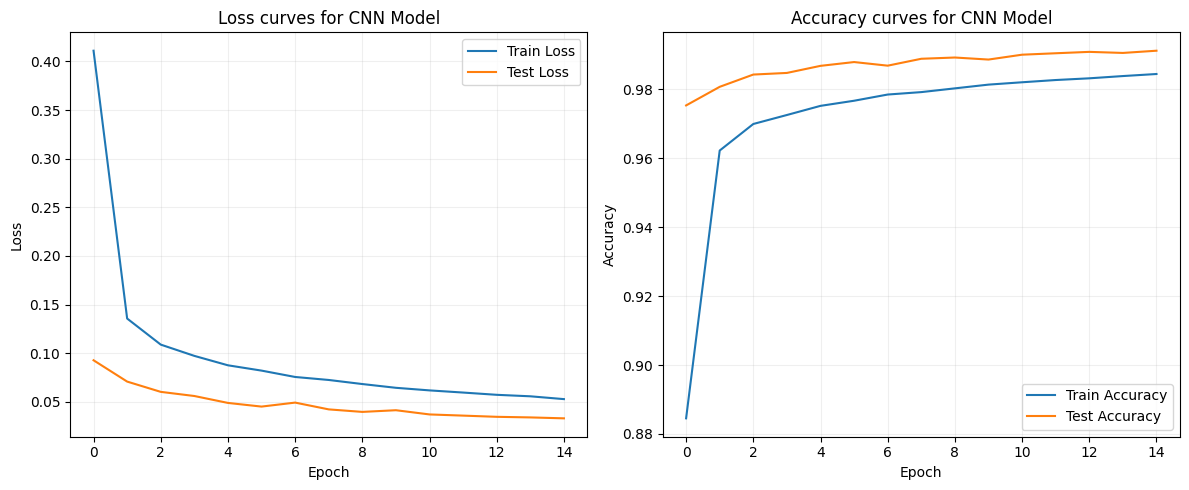

In [43]:
plot_learning_curves(cnn_history, model_name='CNN Model')

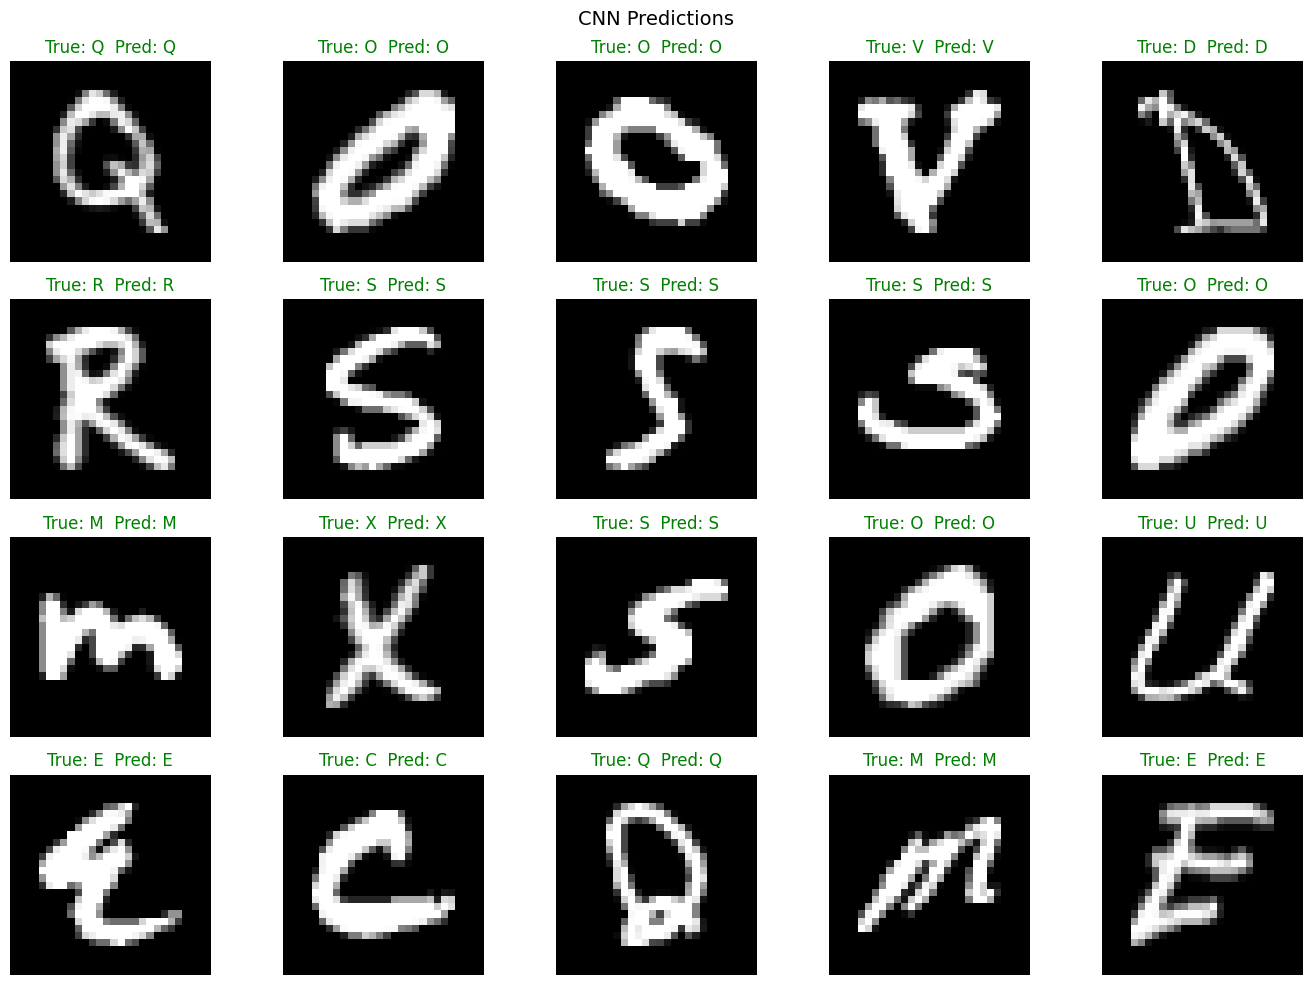

In [44]:
plot_predictions(model=cnn_model, model_name='CNN')

## Models comparishon (Metrics DataFrame)

In [45]:
if best_linear_state is not None:
    linear_model.load_state_dict(best_linear_state)
if best_cnn_state is not None:
    cnn_model.load_state_dict(best_cnn_state)

final_linear_loss, final_linear_acc = test_loop(test_loader, linear_model, loss_fn)
final_cnn_loss,    final_cnn_acc    = test_loop(test_loader, cnn_model,    loss_fn)

pd.DataFrame({
    'Model': ['Linear','CNN'],
    'Parameters': [f'{linear_params:,}',f'{cnn_params:,}'],
    'Best Test Acc': [f'{100*best_linear_acc:.2f}%',f'{100*best_cnn_acc:.2f}%'],
    'Final Test Acc': [f'{100*final_linear_acc:.2f}%',f'{100*final_cnn_acc:.2f}%'],
    'Final Test Loss': [f'{final_linear_loss:.4f}',f'{final_cnn_loss:.4f}'],
})

Test  — Loss: 0.0363, Accuracy: 99.0%
Test  — Loss: 0.0330, Accuracy: 99.1%


,Model,Parameters,Best Test Acc,Final Test Acc,Final Test Loss
0,Linear,"541,466",99.01%,99.01%,0.0363
1,CNN,"423,898",99.12%,99.12%,0.0330


## Conclusion

Two models were trained to classify handwritten letters A–Z (26 classes) on 28×28 grayscale images.

CNN achieves slightly higher accuracy with fewer parameters and converges faster —
it starts at 97.8% from epoch 0 because convolutional filters naturally capture
spatial structure (edges, strokes) that a flat linear layer has to learn from scratch.

Both models show a healthy gap between train and test accuracy, this is expected,
not overfitting: `Dropout` randomly disables neurons during training, so train accuracy is lower. At eval time Dropout is off and the model runs at full capacity.

Neither curve has fully plateaued, meaning additional epochs would likely push both
models further. The CNN in particular was stopped early and has more room to grow.